# Business Understanding

## Project Domain

Domain: Environmental Monitoring & Safety
Sub-Domain: Air Quality Monitoring & Early Fire Detection Systems

Sistem deteksi asap (Smoke Detection System) termasuk dalam bidang pemantauan lingkungan yang berfokus pada keselamatan dan pencegahan bencana. Dengan memanfaatkan data sensor lingkungan seperti suhu, kelembaban, konsentrasi gas, dan partikel udara, sistem ini menggunakan machine learning untuk mendeteksi potensi kebakaran atau kebocoran gas secara dini. Teknologi ini sangat penting dalam industri, perumahan, dan area rentan kebakaran karena dapat mempercepat respons terhadap bahaya, meminimalkan kerusakan, serta melindungi nyawa dan aset.

## Problem Statements

- Deteksi Asap dan Kebakaran yang Terlambat
Banyak sistem konvensional mengandalkan deteksi visual atau manual yang cenderung lambat dalam mengenali keberadaan asap atau potensi kebakaran, sehingga meningkatkan risiko kerusakan besar.

- Kurangnya Sistem Pemantauan Lingkungan yang Real-Time
Pemantauan kualitas udara dan deteksi asap secara real-time masih jarang diterapkan secara luas, terutama di area industri, hutan, atau pemukiman padat.

- Ketergantungan pada Inspeksi Manual
Inspeksi keamanan dan pemantauan kualitas udara secara manual memakan waktu dan rentan terhadap human error, terutama dalam mendeteksi kondisi awal yang bisa menyebabkan kebakaran.

- Keterbatasan Sumber Daya untuk Pencegahan Dini
Banyak organisasi atau masyarakat tidak memiliki akses ke sistem pendeteksian dini yang terjangkau dan andal, yang dapat mencegah kebakaran sebelum menyebar.

- Tingginya Risiko terhadap Keselamatan Manusia dan Aset
Keterlambatan dalam mendeteksi asap dapat mengancam keselamatan jiwa, menyebabkan kerugian ekonomi besar, serta merusak lingkungan secara luas.

## Goals

Membangun sistem berbasis AI (Artificial Neural Network) yang mampu mendeteksi keberadaan asap atau potensi kebakaran secara akurat dan real-time berdasarkan parameter sensor lingkungan berikut:

- Suhu Lingkungan (Temperature [°C])

- Kelembaban Udara (Humidity [%])

- Kualitas Udara (TVOC [ppb], eCO2 [ppm])

- Konsentrasi Gas (Raw H2, Raw Ethanol)

- Tekanan Udara (Pressure [hPa])

- Jumlah Partikel di Udara (PM1.0, PM2.5, NC0.5, NC1.0, NC2.5)

Tujuan sistem ini adalah untuk memberikan peringatan dini terhadap kemungkinan terjadinya kebakaran, mengurangi ketergantungan pada deteksi manual, serta meningkatkan keselamatan lingkungan dan manusia melalui pemantauan otomatis dan prediktif.

## Solution Statements

- Model Machine Learning Menggunakan Artificial Neural Network (ANN)
Membangun model klasifikasi berbasis ANN untuk mendeteksi keberadaan asap (Smoke Detection) berdasarkan data sensor lingkungan seperti suhu, kelembaban, dan kualitas udara. Model dilatih untuk mencapai akurasi tinggi dalam membedakan kondisi normal dan potensi kebakaran.

- Aplikasi Web (Streamlit)
Mengembangkan antarmuka web interaktif menggunakan Streamlit, sehingga pengguna (misalnya petugas keamanan atau operator industri) dapat memasukkan data sensor secara manual atau terhubung ke data real-time untuk mendapatkan hasil deteksi secara instan.

- Optimasi dengan TensorFlow Lite
Model dikonversi ke format TensorFlow Lite agar dapat dijalankan pada perangkat edge seperti sensor IoT atau sistem monitoring portabel, memungkinkan deteksi asap secara langsung di lapangan dengan sumber daya terbatas.



# Data Understanding

## Import data dari kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muhammadfariz12","key":"dd5a5a1cd31a1118533e4654bcd1a25a"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [42]:
!kaggle datasets download -d deepcontractor/smoke-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/deepcontractor/smoke-detection-dataset
License(s): other


In [44]:
!mkdir smoke-detection-dataset
!unzip smoke-detection-dataset.zip -d smoke-detection-dataset
!ls smoke-detection-dataset

Archive:  smoke-detection-dataset.zip
  inflating: smoke-detection-dataset/smoke_detection_iot.csv  
smoke_detection_iot.csv


## Import Library yang dibutuhkan

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [5]:
df = pd.read_csv('/content/smoke-detection-dataset.zip')

In [6]:
df.head()

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      62630 non-null  int64  
 1   UTC             62630 non-null  int64  
 2   Temperature[C]  62630 non-null  float64
 3   Humidity[%]     62630 non-null  float64
 4   TVOC[ppb]       62630 non-null  int64  
 5   eCO2[ppm]       62630 non-null  int64  
 6   Raw H2          62630 non-null  int64  
 7   Raw Ethanol     62630 non-null  int64  
 8   Pressure[hPa]   62630 non-null  float64
 9   PM1.0           62630 non-null  float64
 10  PM2.5           62630 non-null  float64
 11  NC0.5           62630 non-null  float64
 12  NC1.0           62630 non-null  float64
 13  NC2.5           62630 non-null  float64
 14  CNT             62630 non-null  int64  
 15  Fire Alarm      62630 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 7.6 MB


In [8]:
df = df.drop(columns=['Unnamed: 0', 'CNT'])

In [9]:
df.head()

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,Fire Alarm
0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0
1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,0
2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,0
3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,0
4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,0


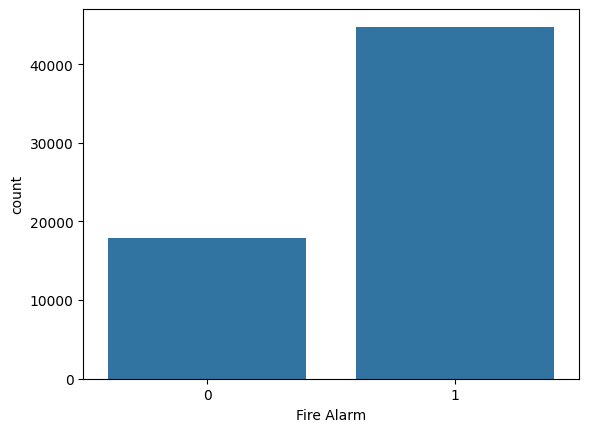

In [10]:
sns.countplot(x='Fire Alarm', data=df)
plt.show()

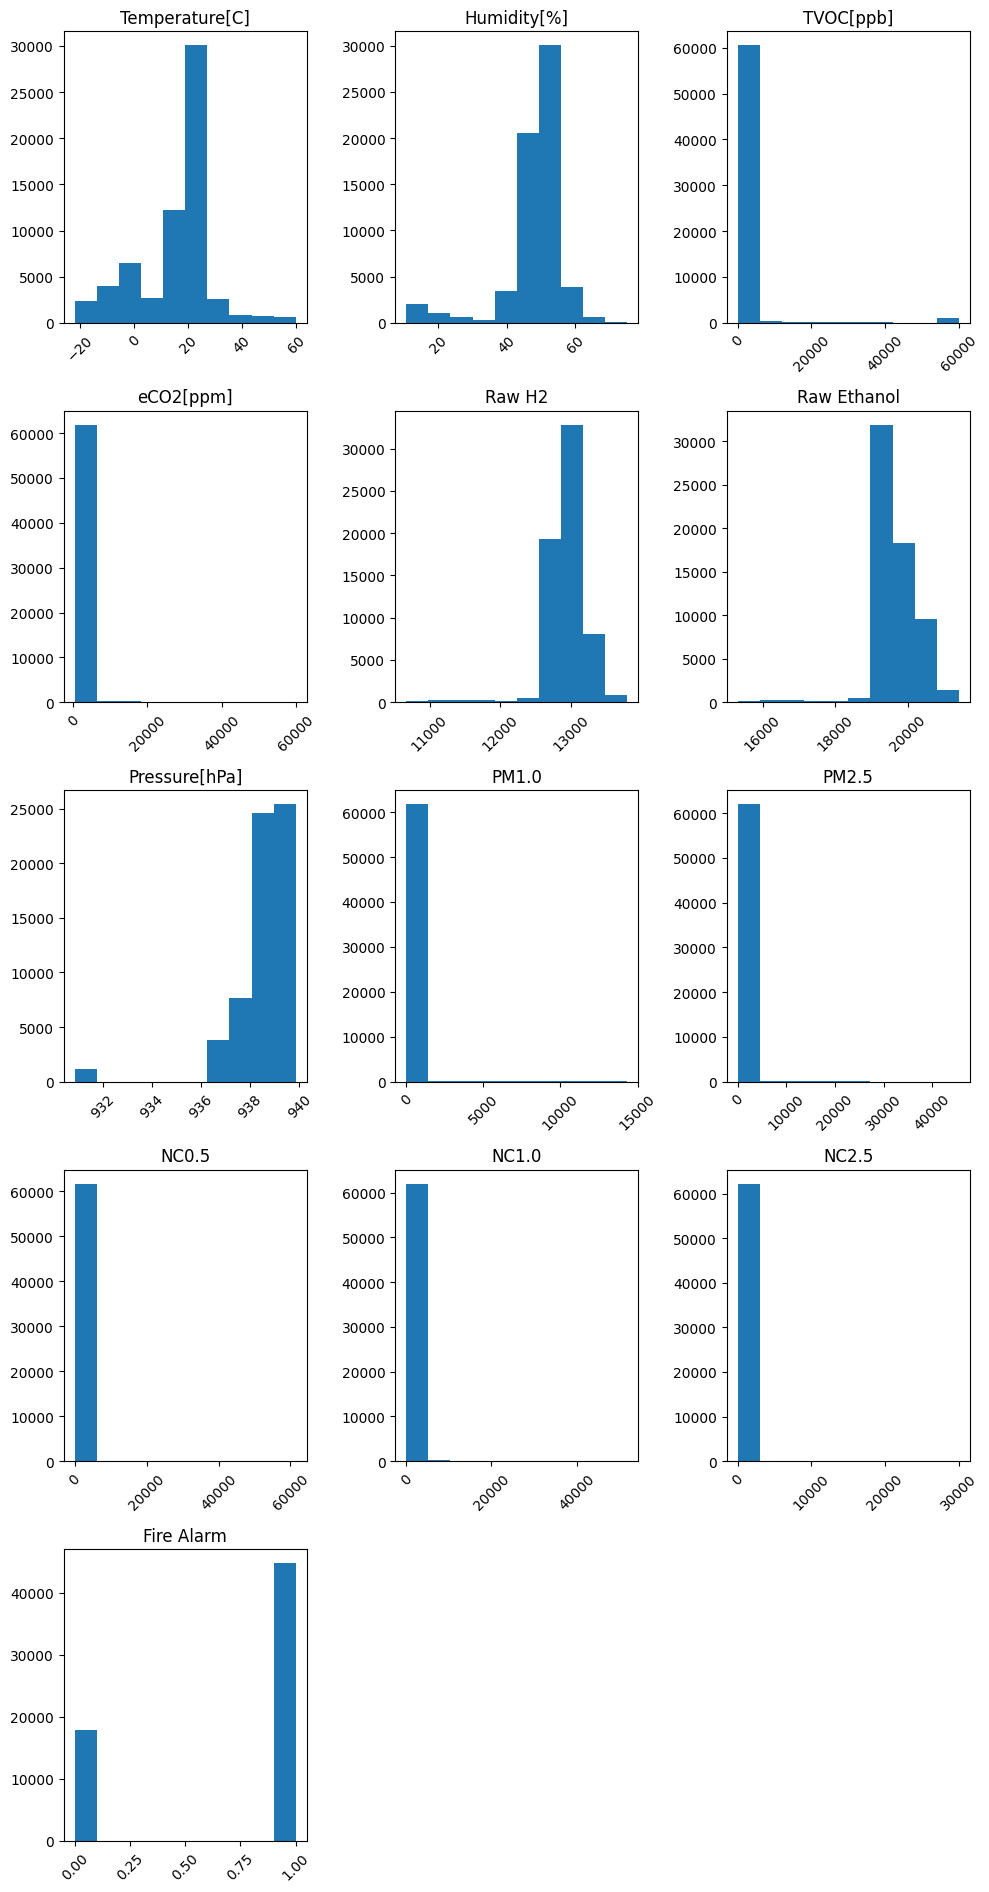

In [11]:
cols = list(df.columns)
cols_df=cols[1:]
plt.figure(figsize=(10,30))
for i in range(len(cols_df)):
    plt.subplot(8,3,i+1)
    plt.title(cols_df[i])
    plt.xticks(rotation=45)
    plt.hist(df[cols_df[i]])

plt.tight_layout()

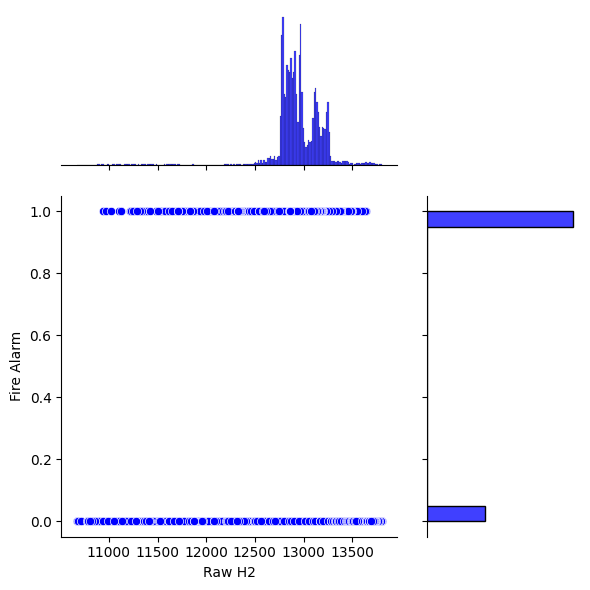

In [12]:
sns.jointplot(x="Raw H2", y="Fire Alarm",  data=df, height=6, ratio=2, color="blue")

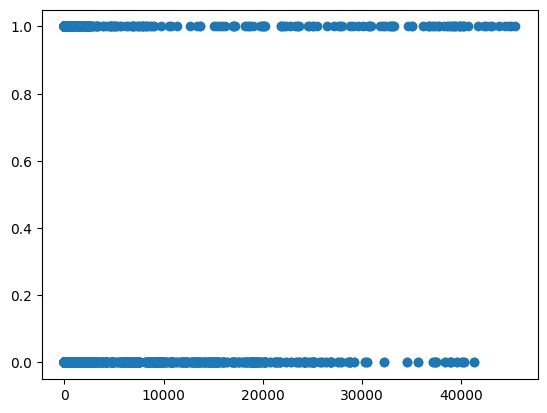

In [13]:
plt.scatter(df["PM2.5"], df["Fire Alarm"])

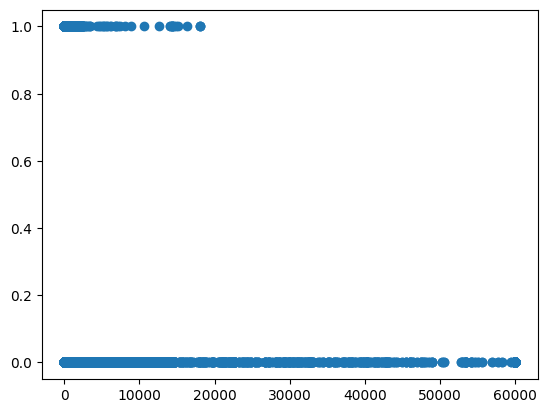

In [16]:
plt.scatter(df["TVOC[ppb]"], df["Fire Alarm"])

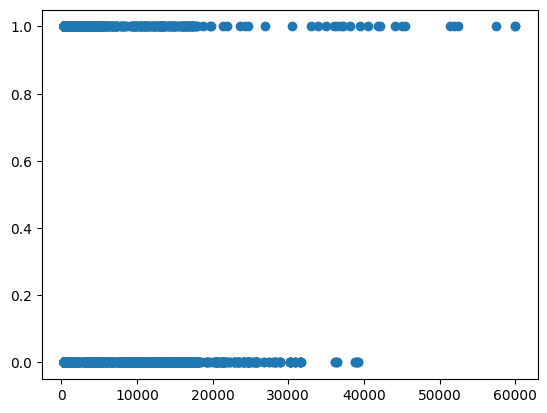

In [18]:
plt.scatter(df["eCO2[ppm]"], df["Fire Alarm"])

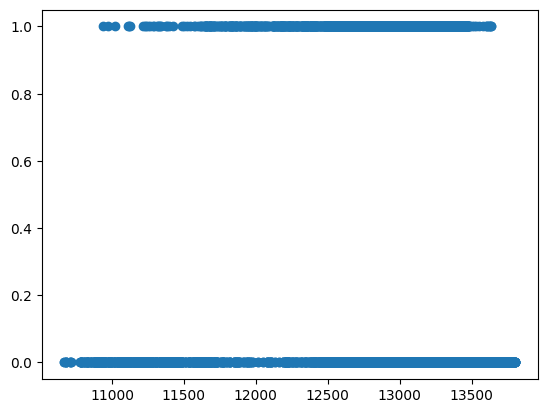

In [19]:
plt.scatter(df["Raw H2"], df["Fire Alarm"])

# Data Preparation

In [78]:
# pisahkan fitur dan target
X = df.drop(columns=["Fire Alarm"])
y = df["Fire Alarm"]

In [79]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [80]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=0)

# Modeling

In [82]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [83]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [84]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,194 (47.63 KB)

 Trainable params: 12,194 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

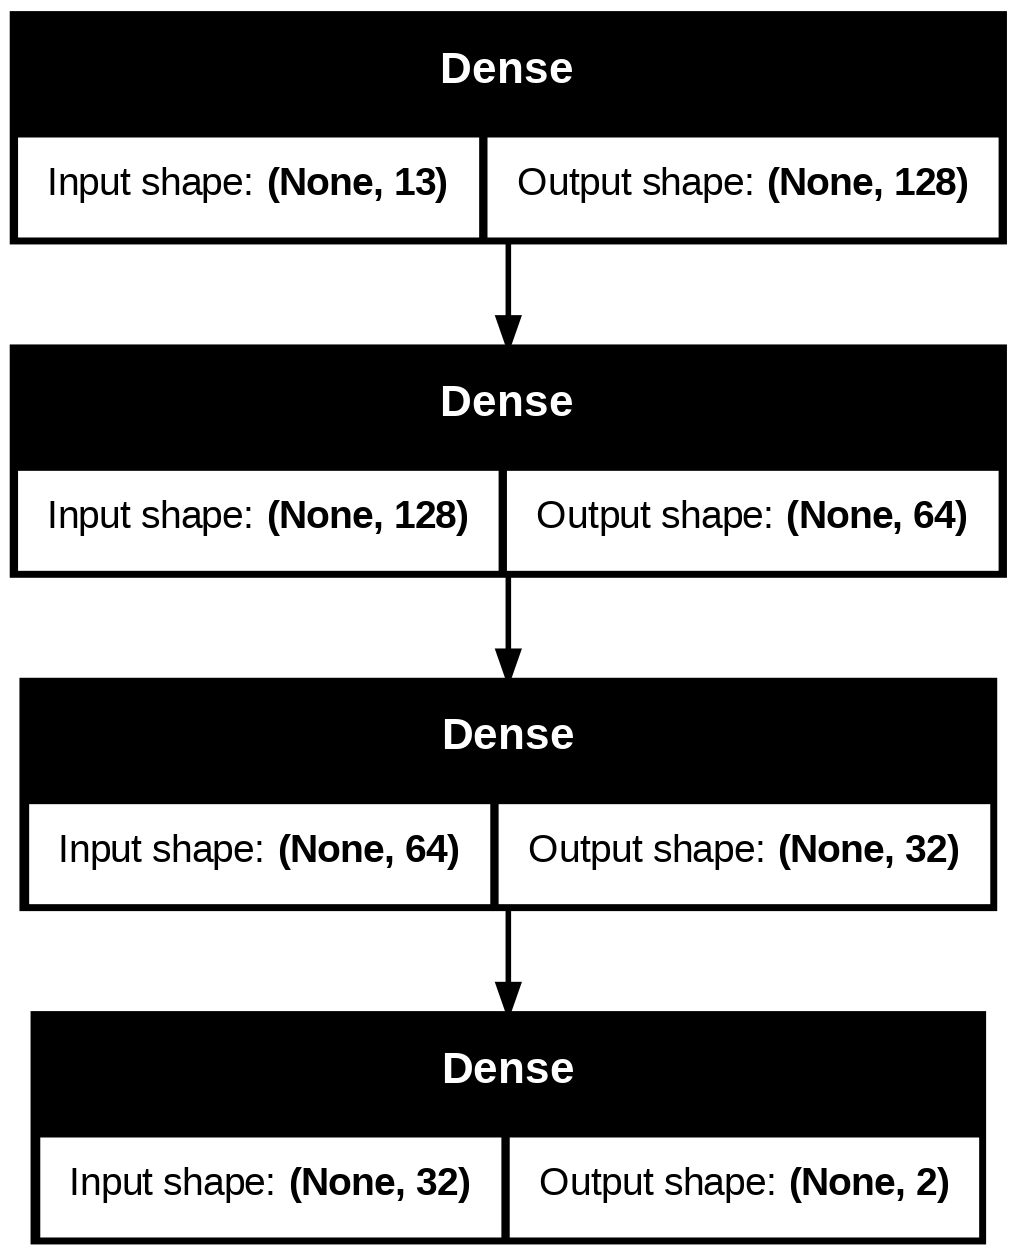

In [85]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [86]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
3132/3132 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9173 - loss: 0.2085 - val_accuracy: 0.9922 - val_loss: 0.0321
Epoch 2/50
3132/3132 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9814 - loss: 0.0470 - val_accuracy: 0.9863 - val_loss: 0.0257
Epoch 3/50
3132/3132 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9850 - loss: 0.0421 - val_accuracy: 0.9717 - val_loss: 0.0498
Epoch 4/50
3132/3132 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9915 - loss: 0.0227 - val_accuracy: 0.9991 - val_loss: 0.0093
Epoch 5/50
3132/3132 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9923 - loss: 0.0232 - val_accuracy: 0.9742 - val_loss: 0.0444
Epoch 6/50
3132/3132 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9907 - loss: 0.0254 - val_accuracy: 0.9989 - val_loss: 0.0064
Epoch 7/50
3132/3132 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9935 - loss: 0.0212 - val_accuracy: 0.9976 - val_loss: 0.0090
Epoch 8/50
3132/3132 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9933 - loss: 0.

# Evaluation

In [87]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9809 - loss: 0.0857
Akurasi Model: 0.9811
Loss Model: 0.0848


In [88]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

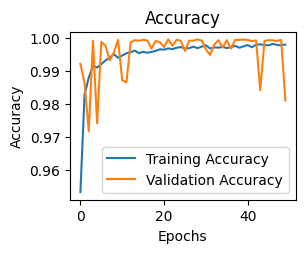

In [89]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

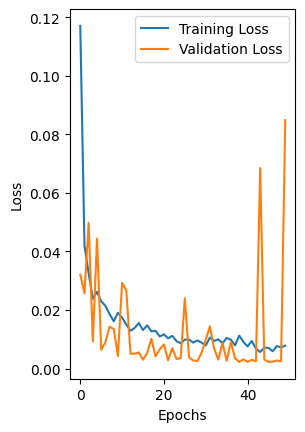

In [90]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


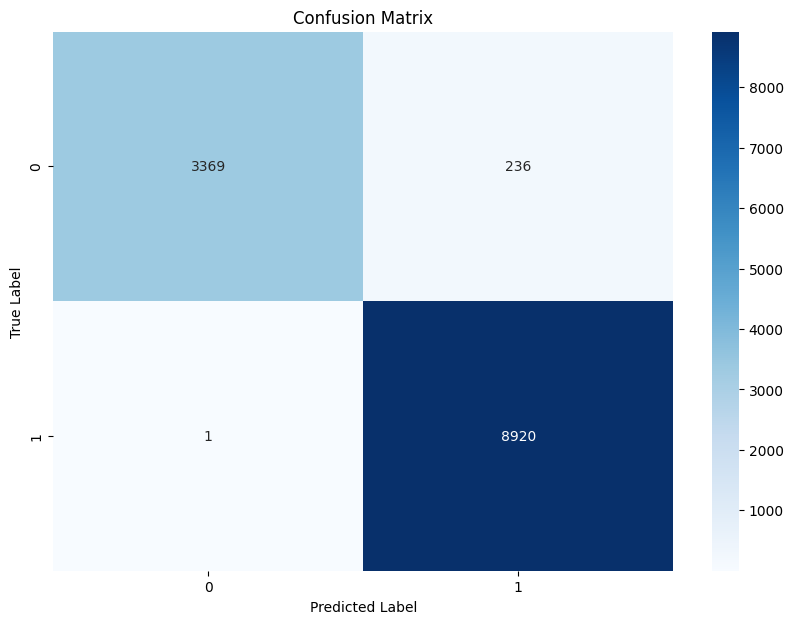

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97      3605
           1       0.97      1.00      0.99      8921

    accuracy                           0.98     12526
   macro avg       0.99      0.97      0.98     12526
weighted avg       0.98      0.98      0.98     12526



In [91]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# **Deployment**

# Model Simulation

In [92]:
sample_input = np.array([[1654733331, 20.000, 57.36, 0, 400, 12306, 18520, 939.735, 0,0,0,0,0]])
sample_input_df = pd.DataFrame(sample_input)

In [93]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [94]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Smoke Detection: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Tanaman yang direkomendasikan: 0


# Save Model

In [95]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmpp_ta_h2l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  133292001816464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133292001813008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133292001815888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133292001816848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133292001817232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133292001814160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133292001815696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133292001813776: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [96]:
# Simpan model
with open('smoke-detection-dataset.tflite', 'wb') as f:
    f.write(tflite_model)

In [97]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']